In [3]:
!wget -O diabetes.csv https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv

--2026-09-08 15:26:53--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23278 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  22.73K  --.-KB/s    in 0s      

2026-09-08 15:26:53 (135 MB/s) - ‘diabetes.csv’ saved [23278/23278]



In [4]:
import pandas as pd

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv("diabetes.csv", names=columns)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (768, 9)


In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [10]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in zero_columns:
    print(column, ":", (df[column] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [11]:
import numpy as np

clean_df = df.copy()

In [12]:
clean_df[zero_columns] = clean_df[zero_columns].replace(0, np.nan)

In [13]:
clean_df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [14]:
import numpy as np

clean_df = df.copy()

clean_df[zero_columns] = clean_df[zero_columns].replace(0, np.nan)

In [15]:
clean_df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [16]:
for column in zero_columns:
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())

In [17]:
clean_df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [18]:
print("Duplicate rows:", clean_df.duplicated().sum())

Duplicate rows: 0


In [19]:
print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)

clean_df.head()

Original shape: (768, 9)
Cleaned shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [20]:
print(clean_df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [21]:
print(clean_df["Outcome"].value_counts(normalize=True) * 100)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


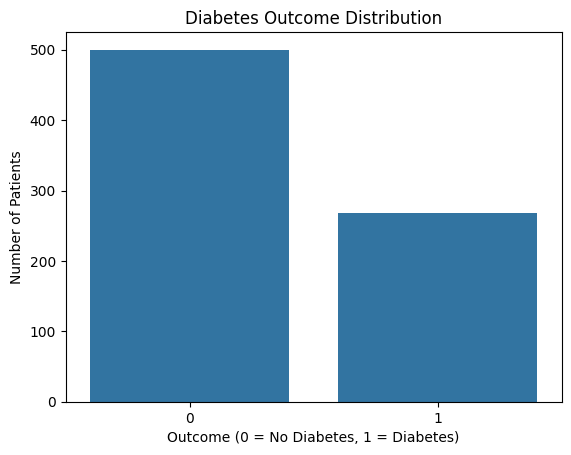

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Outcome", data=clean_df)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

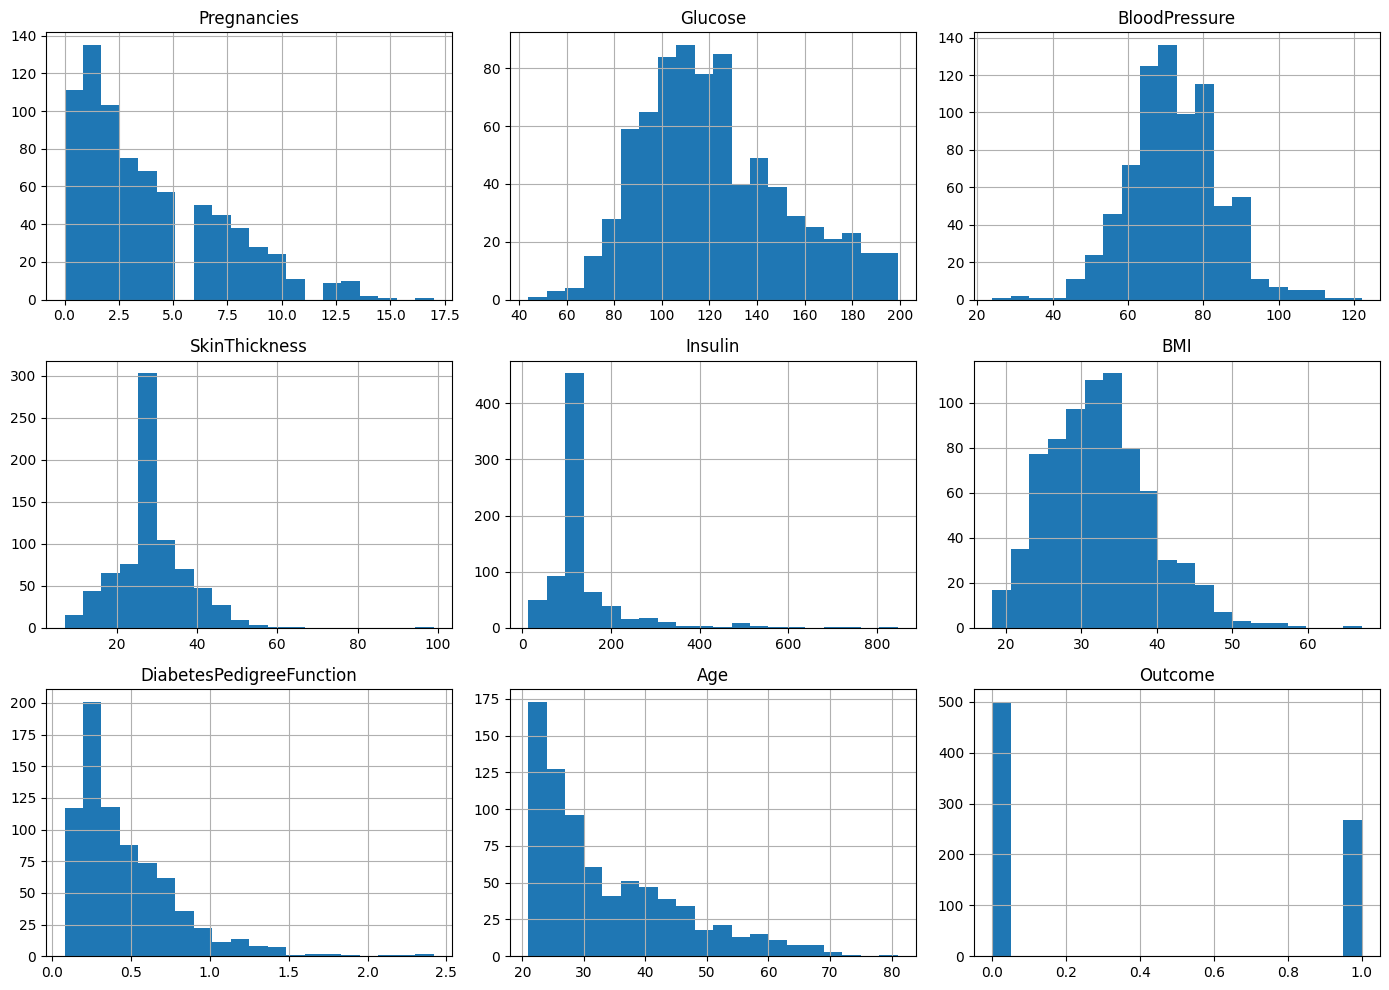

In [23]:
clean_df.hist(
    figsize=(14, 10),
    bins=20
)

plt.tight_layout()
plt.show()

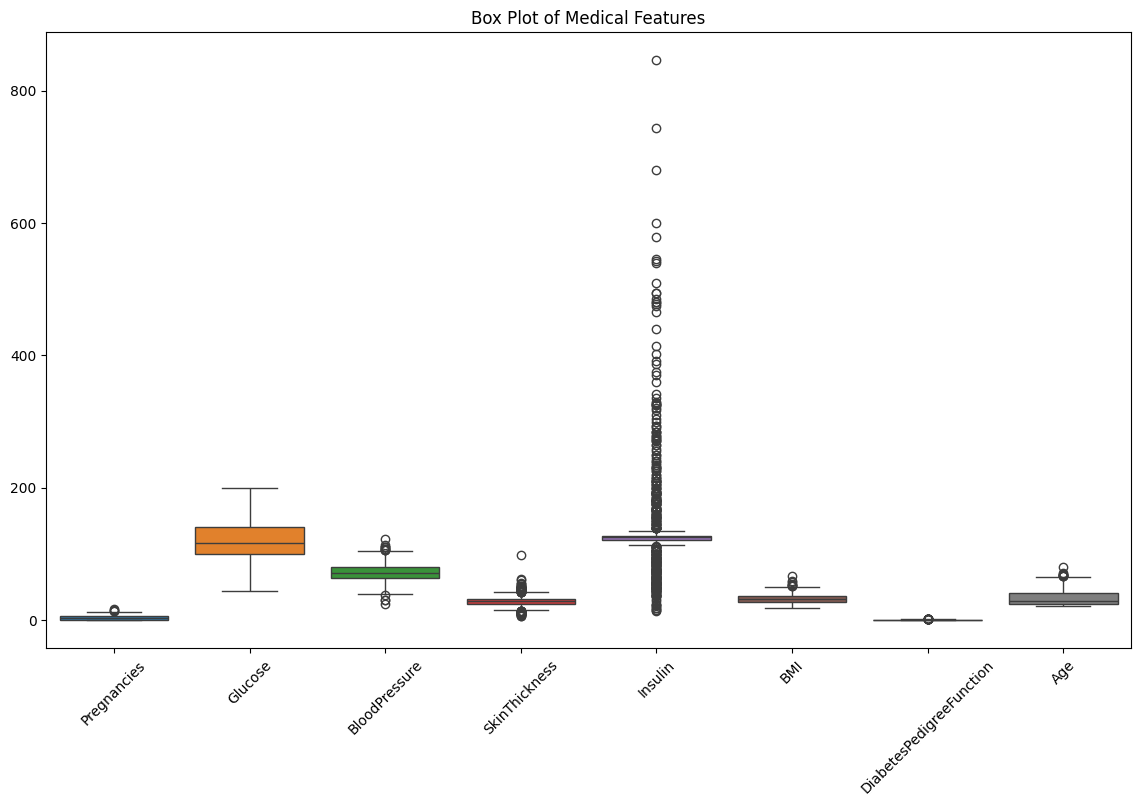

In [24]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=clean_df.drop(columns=["Outcome"]))

plt.title("Box Plot of Medical Features")
plt.xticks(rotation=45)

plt.show()

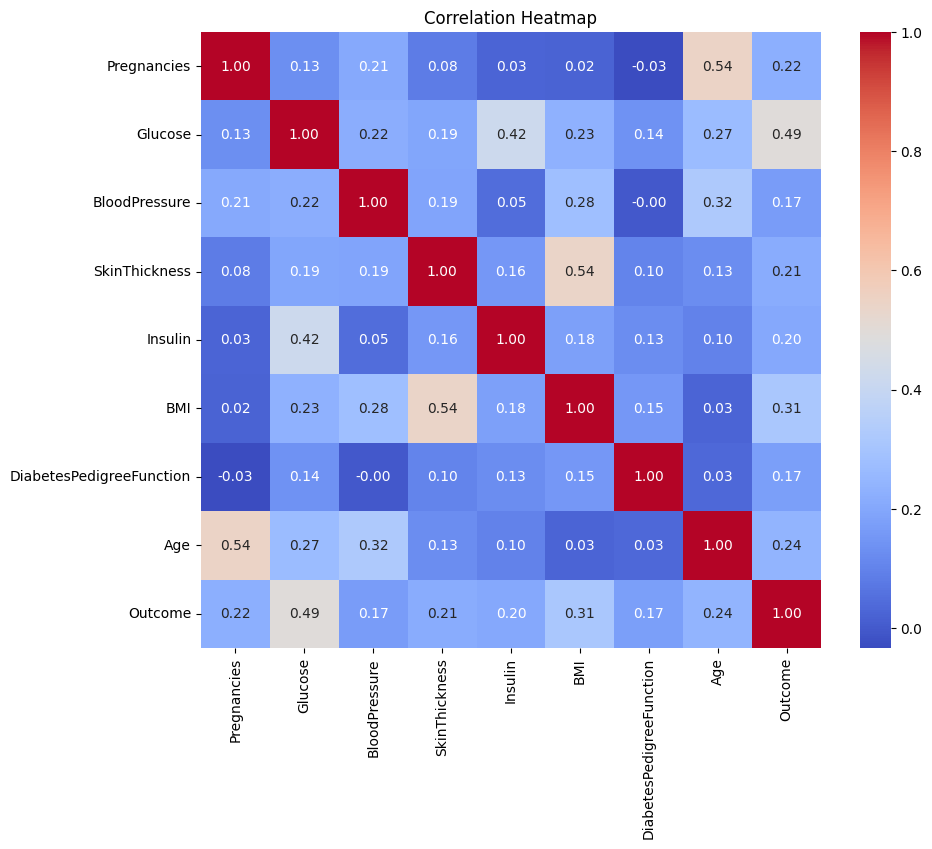

In [25]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    clean_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

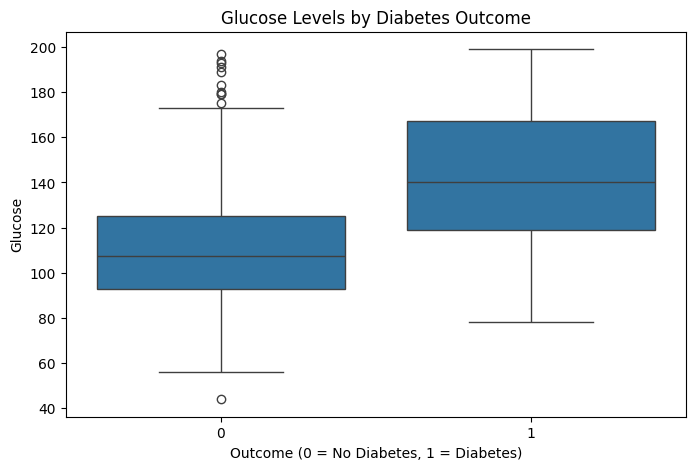

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Outcome",
    y="Glucose",
    data=clean_df
)

plt.title("Glucose Levels by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Glucose")

plt.show()

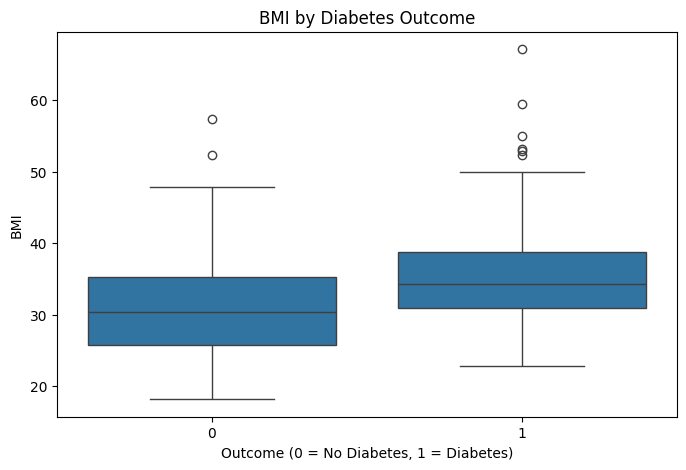

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Outcome",
    y="BMI",
    data=clean_df
)

plt.title("BMI by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("BMI")

plt.show()

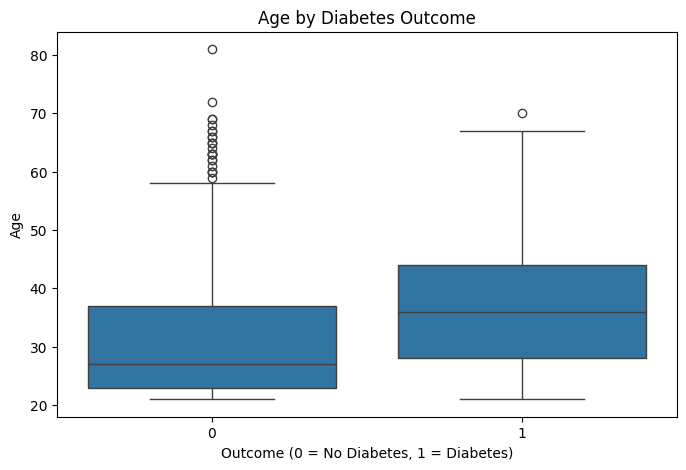

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Outcome",
    y="Age",
    data=clean_df
)

plt.title("Age by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Age")

plt.show()

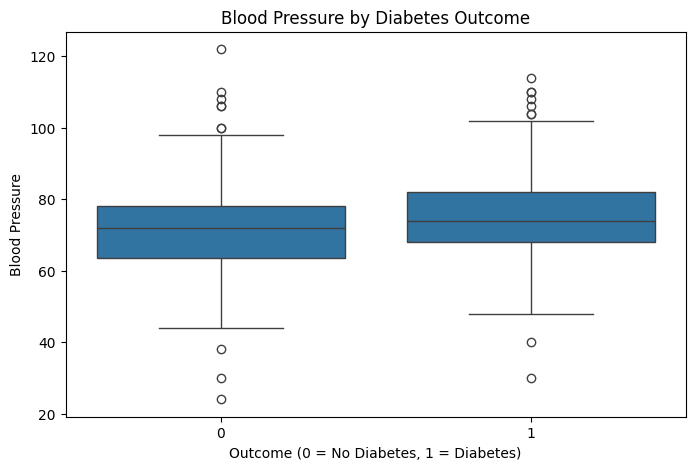

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Outcome",
    y="BloodPressure",
    data=clean_df
)

plt.title("Blood Pressure by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Blood Pressure")

plt.show()

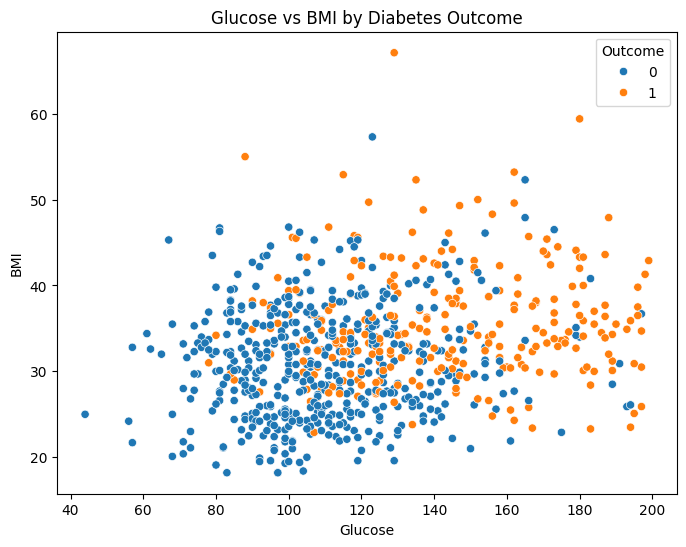

In [30]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=clean_df,
    x="Glucose",
    y="BMI",
    hue="Outcome"
)

plt.title("Glucose vs BMI by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("BMI")

plt.show()

In [31]:
clean_df.groupby("Outcome").mean(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


In [32]:
clean_df["BMI_Category"] = pd.cut(
    clean_df["BMI"],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

In [33]:
clean_df["BMI_Category"].value_counts()

,count
BMI_Category,
Obese,476
Overweight,180
Normal,108
Underweight,4


In [34]:
pd.crosstab(
    clean_df["BMI_Category"],
    clean_df["Outcome"],
    normalize="index"
) * 100

Outcome,0,1
BMI_Category,,
Underweight,100.000000,0.000000
Normal,93.518519,6.481481
Overweight,75.555556,24.444444
Obese,54.411765,45.588235


In [35]:
clean_df["Age_Group"] = pd.cut(
    clean_df["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["≤30", "31-40", "41-50", "51-60", "60+"]
)

In [36]:
clean_df["Age_Group"].value_counts().sort_index()

,count
Age_Group,
≤30,417
31-40,157
41-50,113
51-60,54
60+,27


In [37]:
pd.crosstab(
    clean_df["Age_Group"],
    clean_df["Outcome"],
    normalize="index"
) * 100

Outcome,0,1
Age_Group,,
≤30,78.417266,21.582734
31-40,51.592357,48.407643
41-50,43.362832,56.637168
51-60,42.592593,57.407407
60+,74.074074,25.925926


In [38]:
analysis_df = clean_df.drop(
    columns=["BMI_Category", "Age_Group"]
)

In [39]:
analysis_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [40]:
from scipy.stats import ttest_ind

In [41]:
non_diabetic = analysis_df[
    analysis_df["Outcome"] == 0
]["Glucose"]

diabetic = analysis_df[
    analysis_df["Outcome"] == 1
]["Glucose"]

In [42]:
print("Mean glucose - Non-diabetic:", non_diabetic.mean())
print("Mean glucose - Diabetic:", diabetic.mean())

Mean glucose - Non-diabetic: 110.682
Mean glucose - Diabetic: 142.13059701492537


In [43]:
t_stat, p_value = ttest_ind(
    non_diabetic,
    diabetic,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -14.852653441079662
P-value: 3.5421485614431447e-41


In [44]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in mean glucose levels.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean glucose levels.")

Reject the null hypothesis.
There is a statistically significant difference in mean glucose levels.


Since the p-value is less than 0.05, the null hypothesis is rejected. Therefore, there is a statistically significant difference in mean glucose levels between diabetic and non-diabetic patients.

In [45]:
contingency_table = pd.crosstab(
    clean_df["BMI_Category"],
    clean_df["Outcome"]
)

print(contingency_table)

Outcome         0    1
BMI_Category          
Underweight     4    0
Normal        101    7
Overweight    136   44
Obese         259  217


In [46]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value)

Chi-square statistic: 73.13331881767633
Degrees of freedom: 3
P-value: 9.101656268510895e-16


In [47]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("BMI category and diabetes outcome are significantly associated.")
else:
    print("Fail to reject the null hypothesis.")
    print("No significant association was found.")

Reject the null hypothesis.
BMI category and diabetes outcome are significantly associated.


In [48]:
print(clean_df["Age_Group"].value_counts().sort_index())

Age_Group
≤30      417
31-40    157
41-50    113
51-60     54
60+       27
Name: count, dtype: int64


In [49]:
age_groups = []

for group in clean_df["Age_Group"].cat.categories:
    values = clean_df[
        clean_df["Age_Group"] == group
    ]["Glucose"]

    age_groups.append(values)

    print(
        group,
        "Mean glucose:",
        values.mean(),
        "Count:",
        len(values)
    )

≤30 Mean glucose: 115.0167865707434 Count: 417
31-40 Mean glucose: 126.92356687898089 Count: 157
41-50 Mean glucose: 125.92035398230088 Count: 113
51-60 Mean glucose: 141.14814814814815 Count: 54
60+ Mean glucose: 136.74074074074073 Count: 27


In [50]:
from scipy.stats import f_oneway

In [51]:
f_stat, p_value = f_oneway(*age_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 14.88955152237089
P-value: 1.008677127887533e-11


In [52]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in mean glucose levels among age groups.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean glucose levels among age groups.")

Reject the null hypothesis.
There is a statistically significant difference in mean glucose levels among age groups.


In [53]:
correlation = analysis_df.corr()["Outcome"].sort_values(ascending=False)

print(correlation)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


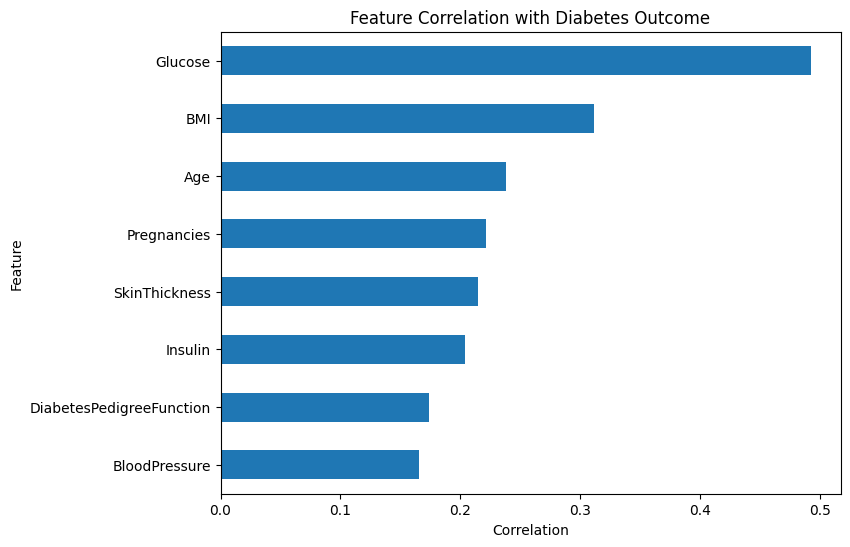

In [54]:
plt.figure(figsize=(8, 6))

correlation.drop("Outcome").sort_values().plot(kind="barh")

plt.title("Feature Correlation with Diabetes Outcome")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

In [55]:
X = analysis_df.drop(columns=["Outcome"])
y = analysis_df["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [57]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496


In [58]:
print(X_scaled_df.mean())

Pregnancies                -6.476301e-17
Glucose                     4.625929e-18
BloodPressure               5.782412e-18
SkinThickness              -1.526557e-16
Insulin                     1.503427e-17
BMI                         2.613650e-16
DiabetesPedigreeFunction    2.451743e-16
Age                         1.931325e-16
dtype: float64


In [59]:
print(X_scaled_df.std())

Pregnancies                 1.000652
Glucose                     1.000652
BloodPressure               1.000652
SkinThickness               1.000652
Insulin                     1.000652
BMI                         1.000652
DiabetesPedigreeFunction    1.000652
Age                         1.000652
dtype: float64


In [60]:
from sklearn.decomposition import PCA

In [61]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [62]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.28537316 0.18694722 0.14268806 0.11456572 0.09610793 0.06790947
 0.05855625 0.0478522 ]


In [63]:
cumulative_variance = explained_variance.cumsum()

print(cumulative_variance)

[0.28537316 0.47232037 0.61500844 0.72957415 0.82568209 0.89359156
 0.9521478  1.        ]


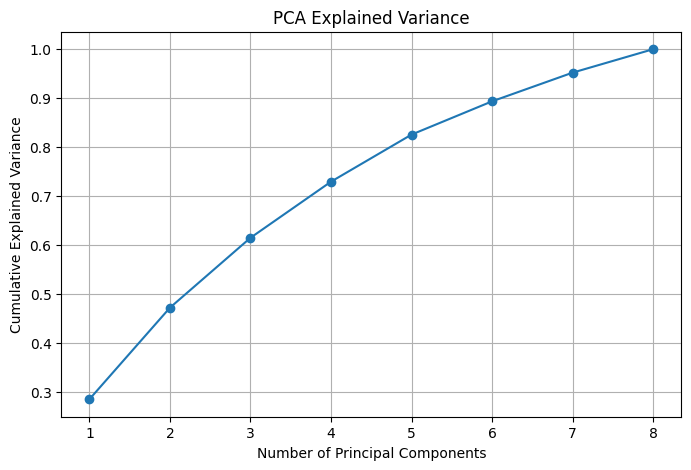

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()

plt.show()

In [65]:
pca_95 = PCA(n_components=0.95)

X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original number of features:", X.shape[1])
print("Number of PCA components:", X_pca_95.shape[1])

Original number of features: 8
Number of PCA components: 7


In [66]:
pca_columns = [
    f"PC{i+1}"
    for i in range(X_pca_95.shape[1])
]

pca_df = pd.DataFrame(
    X_pca_95,
    columns=pca_columns
)

pca_df["Outcome"] = y.values

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,Outcome
0,1.449481,0.659769,0.170348,0.581229,-0.429600,0.781267,-0.399023,1
1,-1.498835,-0.076049,-0.237154,-0.083245,-0.245135,-0.396642,-0.912313,0
2,0.423246,0.761327,1.635241,0.407786,-0.427015,1.542613,0.423186,1
3,-2.152468,-0.166717,-0.407486,-0.614716,0.083360,-0.207993,-0.020214,0
4,0.697836,-3.548952,1.872157,4.744194,-1.005226,0.709645,0.069886,1


In [67]:
print("Final PCA dataset shape:", pca_df.shape)

Final PCA dataset shape: (768, 8)


In [68]:
clean_df.to_csv(
    "pima_cleaned.csv",
    index=False
)

pca_df.to_csv(
    "pima_pca.csv",
    index=False
)

print("Files saved successfully!")

Files saved successfully!
